# 05 — Advanced Anomaly Detection

## Project: Sales Anomaly Detection for a Multi-Outlet F&B Business

### Objective

The goal of this notebook is to apply unsupervised machine learning methods for anomaly detection and compare their results against the baseline statistical anomaly flags created in the previous notebook.

The main algorithm used in this notebook is Isolation Forest.

### Why advanced anomaly detection?

The baseline anomaly detection notebook used rolling z-score rules to detect transaction volume and revenue anomalies.

Those rules are interpretable and useful, but they mainly detect anomalies based on individual features crossing thresholds.

Machine learning methods such as Isolation Forest can detect multivariate anomalies, where a row may look unusual because of the combination of multiple features, even if no single feature is extreme enough by itself.

### Input dataset

The main input dataset is:

`daily_outlet_baseline_anomaly_flags.csv`

This dataset contains one row per outlet per date and includes:

- transaction count features,
- paid revenue features,
- rolling z-score features,
- percentage change features,
- baseline anomaly flags,
- anomaly type information.

### Expected outcome

By the end of this notebook, we should be able to:

- apply Isolation Forest to detect anomaly candidates,
- generate machine learning anomaly scores,
- compare ML anomalies with baseline anomalies,
- inspect ML-only and baseline-only anomalies,
- evaluate whether ML adds value beyond the statistical baseline.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
# Load the dataset created in Notebook 4
features = pd.read_csv(
    "../data/processed/daily_outlet_baseline_anomaly_flags.csv"
)

# Convert date column to datetime
features["date"] = pd.to_datetime(features["date"], errors="coerce")

# Sort by outlet and date for consistency
features = features.sort_values(["outlet", "date"]).reset_index(drop=True)

# Basic checks
print("Features shape:", features.shape)
print("Date range:", features["date"].min(), "to", features["date"].max())
print("Unique outlets:", features["outlet"].nunique())
print("Outlets:", features["outlet"].unique())

# Preview
features.head()


Features shape: (807, 33)
Date range: 2025-01-05 00:00:00 to 2025-09-30 00:00:00
Unique outlets: 3
Outlets: ['SHOP001' 'SHOP002' 'SHOP003']


,date,outlet,transaction_count,total_revenue,avg_transaction_value,total_items,avg_basket_size,zero_value_transactions,day_name,day_of_week,is_weekend,month,tx_lag_1,rev_lag_1_x,tx_roll_mean_7,tx_roll_std_7,tx_diff_from_roll7,tx_zscore_roll7,tx_pct_change_1d,paid_revenue,rev_lag_1_y,rev_roll_mean_7,rev_roll_std_7,rev_diff_from_roll7,rev_zscore_roll7,rev_pct_change_1d,tx_spike_flag,tx_drop_flag,rev_spike_flag,rev_drop_flag,baseline_anomaly_flag,max_abs_zscore,anomaly_type
0,2025-01-05,SHOP001,90,2114000,23488.888889,106,1.177778,3,Sunday,6,1,1,99.0,2473000.0,94.000000,10.440307,-4.000000,-0.383130,-0.090909,2114000,2473000.0,2.357000e+06,308797.668385,-243000.000000,-0.786923,-0.145168,0,0,0,0,0,0.786923,Other
1,2025-01-06,SHOP001,82,1885000,22987.804878,90,1.097561,2,Monday,0,0,1,90.0,2114000.0,93.000000,8.755950,-11.000000,-1.256288,-0.088889,1885000,2114000.0,2.296250e+06,279880.182697,-411250.000000,-1.469379,-0.108325,0,0,0,0,0,1.469379,Other
2,2025-01-07,SHOP001,96,2472000,25750.000000,111,1.156250,1,Tuesday,1,0,1,82.0,1885000.0,90.800000,9.038805,5.200000,0.575297,0.170732,2472000,1885000.0,2.214000e+06,304261.400772,258000.000000,0.847955,0.311406,0,0,0,0,0,0.847955,Other
3,2025-01-08,SHOP001,110,2646000,24054.545455,125,1.136364,1,Wednesday,2,0,1,96.0,2472000.0,91.666667,8.358628,18.333333,2.193342,0.145833,2646000,2472000.0,2.257000e+06,291811.583046,389000.000000,1.333052,0.070388,0,0,0,0,0,2.193342,Other
4,2025-01-09,SHOP001,72,1959000,27208.333333,85,1.180556,1,Thursday,3,0,1,110.0,2646000.0,94.285714,10.307187,-22.285714,-2.162153,-0.345455,1959000,2646000.0,2.312571e+06,304267.895745,-353571.428571,-1.162040,-0.259637,0,0,0,0,0,2.162153,Other


In [4]:
# Check that the main baseline anomaly columns exist
required_cols = [
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "avg_transaction_value",
    "zero_value_transactions",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_pct_change_1d",
    "rev_pct_change_1d",
    "baseline_anomaly_flag"
]

missing_cols = [
    col for col in required_cols
    if col not in features.columns
]

print("Missing required columns:", missing_cols)

Missing required columns: []


In [5]:
features[required_cols].head()

,date,outlet,transaction_count,paid_revenue,avg_transaction_value,zero_value_transactions,tx_zscore_roll7,rev_zscore_roll7,tx_pct_change_1d,rev_pct_change_1d,baseline_anomaly_flag
0,2025-01-05,SHOP001,90,2114000,23488.888889,3,-0.383130,-0.786923,-0.090909,-0.145168,0
1,2025-01-06,SHOP001,82,1885000,22987.804878,2,-1.256288,-1.469379,-0.088889,-0.108325,0
2,2025-01-07,SHOP001,96,2472000,25750.000000,1,0.575297,0.847955,0.170732,0.311406,0
3,2025-01-08,SHOP001,110,2646000,24054.545455,1,2.193342,1.333052,0.145833,0.070388,0
4,2025-01-09,SHOP001,72,1959000,27208.333333,1,-2.162153,-1.162040,-0.345455,-0.259637,0


## Step 2 — Select Machine Learning Features

### What we are doing

In this step, we select the numeric features that will be used as input to the Isolation Forest model.

The model will use these features to learn what normal outlet-day behavior looks like and identify unusual combinations of values.

### Why we are doing this

Isolation Forest does not understand business context directly.

It only receives numeric input features.

Therefore, feature selection is important because the selected columns determine what patterns the model can detect.

### Features selected

The selected features include:

- transaction count
- paid revenue
- average transaction value
- zero-value transaction count
- transaction count rolling z-score
- paid revenue rolling z-score
- transaction count day-over-day percentage change
- paid revenue day-over-day percentage change

### Important note

The baseline anomaly flag is not used as an input feature.

It will only be used later for comparison with the Isolation Forest output.

In [6]:
ml_features = [
    "transaction_count",
    "paid_revenue",
    "avg_transaction_value",
    "zero_value_transactions",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_pct_change_1d",
    "rev_pct_change_1d"
]

X = features[ml_features].copy()

X.head()


,transaction_count,paid_revenue,avg_transaction_value,zero_value_transactions,tx_zscore_roll7,rev_zscore_roll7,tx_pct_change_1d,rev_pct_change_1d
0,90,2114000,23488.888889,3,-0.383130,-0.786923,-0.090909,-0.145168
1,82,1885000,22987.804878,2,-1.256288,-1.469379,-0.088889,-0.108325
2,96,2472000,25750.000000,1,0.575297,0.847955,0.170732,0.311406
3,110,2646000,24054.545455,1,2.193342,1.333052,0.145833,0.070388
4,72,1959000,27208.333333,1,-2.162153,-1.162040,-0.345455,-0.259637


In [7]:
print("ML feature matrix shape:", X.shape)

X.isna().sum()

ML feature matrix shape: (807, 8)


transaction_count          0
paid_revenue               0
avg_transaction_value      0
zero_value_transactions    0
tx_zscore_roll7            0
rev_zscore_roll7           0
tx_pct_change_1d           0
rev_pct_change_1d          0
dtype: int64

## Step 3 — Scale Machine Learning Features

### What we are doing percentage change features are much smaller.### What we are doing

### Why we are doing this

Scaling helps place features on a comparable numeric scale before applying machine learning models.

Although Isolation Forest is less sensitive to scaling than distance-based models, scaling is useful because future models such as Local Outlier Factor or One-Class SVM are strongly affected by feature scale.

### Expected outcome

The scaled feature matrix will have the same number of rows and columns as the original feature matrix, but the values will be standardized.

In this step, we scale the selected machine learning features using standard scaling.



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original feature matrix shape:", X.shape)
print("Scaled feature matrix shape:", X_scaled.shape)

Original feature matrix shape: (807, 8)
Scaled feature matrix shape: (807, 8)


In [9]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=ml_features
)

X_scaled_df.head()

,transaction_count,paid_revenue,avg_transaction_value,zero_value_transactions,tx_zscore_roll7,rev_zscore_roll7,tx_pct_change_1d,rev_pct_change_1d
0,0.884169,0.741423,-0.575210,0.567100,-0.295989,-0.602947,-0.525310,-0.705165
1,0.589644,0.402759,-0.896607,-0.073866,-0.930555,-1.110286,-0.515918,-0.555458
2,1.105063,1.270864,0.875071,-0.714832,0.400548,0.612424,0.691023,1.150096
3,1.620483,1.528189,-0.212397,-0.714832,1.576460,0.973046,0.575274,0.170735
4,0.221487,0.512196,1.810450,-0.714832,-1.588891,-0.881810,-1.708657,-1.170305


In [10]:
X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_count,807.0,-7.043794e-17,1.00062,-1.913822,-0.919799,-0.036223,0.810538,2.651322
paid_revenue,807.0,-1.056569e-16,1.00062,-1.892470,-0.923061,-0.043864,0.784311,2.433267
avg_transaction_value,807.0,1.954653e-15,1.00062,-4.122522,-0.589535,0.032203,0.615353,3.881645
zero_value_transactions,807.0,-5.282846e-17,1.00062,-1.355797,-0.714832,-0.073866,0.567100,3.771928
tx_zscore_roll7,807.0,2.256215e-17,1.00062,-4.575171,-0.612135,-0.047760,0.568883,9.156163
rev_zscore_roll7,807.0,-1.100593e-18,1.00062,-4.526957,-0.626200,-0.038585,0.570446,5.992447
tx_pct_change_1d,807.0,-1.650889e-17,1.00062,-3.430851,-0.656550,-0.102685,0.505631,5.475954
rev_pct_change_1d,807.0,-1.100593e-18,1.00062,-3.195369,-0.663791,-0.109520,0.559215,5.510082


## Step 3 Findings — Feature Scaling

The selected machine learning features were scaled using standard scaling.

After scaling, the feature means are approximately 0 and the standard deviations are approximately 1.

This confirms that the features are now on comparable numeric scales.

Scaling is useful because the selected features originally had very different units and ranges, such as revenue values in millions, transaction counts in tens or hundreds, and z-score or percentage-change features in smaller numeric ranges.

The scaled data is now ready for Isolation Forest modeling.

## Step 4 — Train Isolation Forest

### What we are doing

In this step, we train an Isolation Forest model using the scaled machine learning feature matrix.

Isolation Forest is an unsupervised anomaly detection algorithm. It identifies rows that are easier to isolate from the rest of the data.

### Why we are doing this

The baseline method used rolling z-score thresholds for individual signals.

Isolation Forest can detect multivariate anomalies, where an outlet-day may be unusual because of the combination of several features.

### Contamination setting

The contamination parameter is set to 0.08.

This means the model is expected to flag approximately 8% of rows as anomalies.

This value was chosen because the baseline anomaly detection method flagged approximately 7.68% of rows.

In [13]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.08,
    random_state=42
)

iso_model.fit(X_scaled)
# n_estimators=300 because it means 300 trees will be built, which can capture complex patterns in the data and improve anomaly detection performance.
# contamination=0.08 because we expect around 8% of the data to be anomalous based on our earlier analysis, so this helps the model set an appropriate threshold for flagging anomalies.
# random_state=42 to ensure reproducibility of results.

,n_estimators,300
,max_samples,'auto'
,contamination,0.08
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [14]:
# sklearn returns 1 for normal and -1 for anomaly
features["iso_prediction_raw"] = iso_model.predict(X_scaled)

# Convert to clearer flag: 0 = normal, 1 = anomaly
features["iso_anomaly_flag"] = (
    features["iso_prediction_raw"] == -1
).astype(int)

# decision_function: higher = more normal
# invert it so higher score = more anomalous
features["iso_score_raw"] = iso_model.decision_function(X_scaled)
features["iso_anomaly_score"] = -features["iso_score_raw"]

features[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "baseline_anomaly_flag",
    "iso_anomaly_flag",
    "iso_anomaly_score"
]].head()

,date,outlet,transaction_count,paid_revenue,baseline_anomaly_flag,iso_anomaly_flag,iso_anomaly_score
0,2025-01-05,SHOP001,90,2114000,0,0,-0.112203
1,2025-01-06,SHOP001,82,1885000,0,0,-0.102232
2,2025-01-07,SHOP001,96,2472000,0,0,-0.086396
3,2025-01-08,SHOP001,110,2646000,0,0,-0.062916
4,2025-01-09,SHOP001,72,1959000,0,0,-0.016789


In [15]:
print("Isolation Forest anomalies:", features["iso_anomaly_flag"].sum())
print("Isolation Forest anomaly rate:", round(features["iso_anomaly_flag"].mean() * 100, 2), "%")

Isolation Forest anomalies: 65
Isolation Forest anomaly rate: 8.05 %


In [16]:
top_iso_anomalies = (
    features
    .sort_values("iso_anomaly_score", ascending=False)
    .head(15)
)

top_iso_anomalies[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "avg_transaction_value",
    "zero_value_transactions",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_pct_change_1d",
    "rev_pct_change_1d",
    "baseline_anomaly_flag",
    "iso_anomaly_flag",
    "iso_anomaly_score"
]]

,date,outlet,transaction_count,paid_revenue,avg_transaction_value,zero_value_transactions,tx_zscore_roll7,rev_zscore_roll7,tx_pct_change_1d,rev_pct_change_1d,baseline_anomaly_flag,iso_anomaly_flag,iso_anomaly_score
147,2025-06-01,SHOP001,138,3185000,23079.710145,8,12.622943,7.645257,0.769231,0.671039,1,1,0.234537
654,2025-05-01,SHOP003,55,1477000,26854.545455,1,6.832124,8.084986,0.896552,1.318681,1,1,0.178904
624,2025-04-01,SHOP003,25,537000,21480.000000,2,-6.271246,-6.065374,-0.715909,-0.757999,1,1,0.162948
355,2025-04-01,SHOP002,22,437000,19863.636364,2,-2.681291,-4.261753,-0.388889,-0.522926,1,1,0.112957
373,2025-04-19,SHOP002,14,393000,28071.428571,1,-1.877348,-1.692586,-0.674419,-0.641423,0,1,0.107205
685,2025-06-01,SHOP003,88,2216000,25181.818182,1,3.603992,3.750038,0.833333,0.848207,1,1,0.105399
385,2025-05-01,SHOP002,33,794000,24060.606061,3,0.701017,0.637142,1.200000,1.384384,0,1,0.094860
335,2025-03-12,SHOP002,47,1206000,25659.574468,2,3.250233,3.898229,0.678571,0.846861,1,1,0.091250
360,2025-04-06,SHOP002,17,478000,28117.647059,0,-2.012723,-1.153784,-0.540541,-0.460497,0,1,0.081891
499,2025-08-23,SHOP002,24,431000,17958.333333,3,-2.467720,-2.666090,-0.250000,-0.377168,1,1,0.077006


In [17]:
features["iso_anomaly_flag"].sum()
round(features["iso_anomaly_flag"].mean() * 100, 2)

np.float64(8.05)

In [18]:
comparison_table = pd.crosstab(
    features["baseline_anomaly_flag"],
    features["iso_anomaly_flag"],
    rownames=["Baseline anomaly"],
    colnames=["Isolation Forest anomaly"]
)

comparison_table

Isolation Forest anomaly,0,1
Baseline anomaly,,
0,712,33
1,30,32


In [19]:
both_anomalous = features[
    (features["baseline_anomaly_flag"] == 1) &
    (features["iso_anomaly_flag"] == 1)
].copy()

baseline_only = features[
    (features["baseline_anomaly_flag"] == 1) &
    (features["iso_anomaly_flag"] == 0)
].copy()

ml_only = features[
    (features["baseline_anomaly_flag"] == 0) &
    (features["iso_anomaly_flag"] == 1)
].copy()

print("Both baseline and Isolation Forest:", len(both_anomalous))
print("Baseline only:", len(baseline_only))
print("Isolation Forest only:", len(ml_only))

Both baseline and Isolation Forest: 32
Baseline only: 30
Isolation Forest only: 33


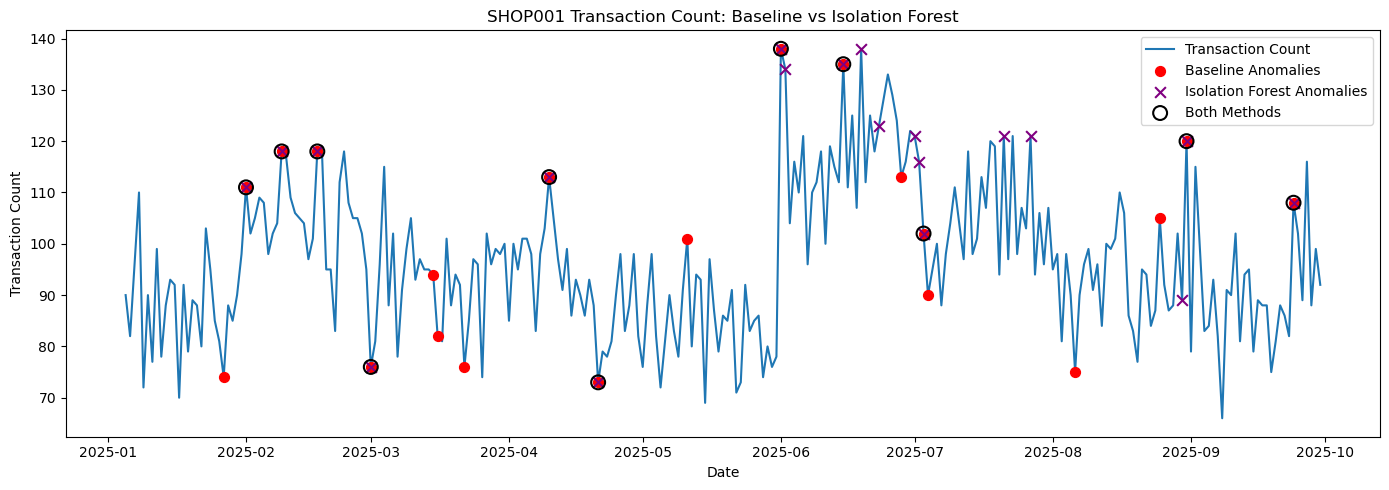

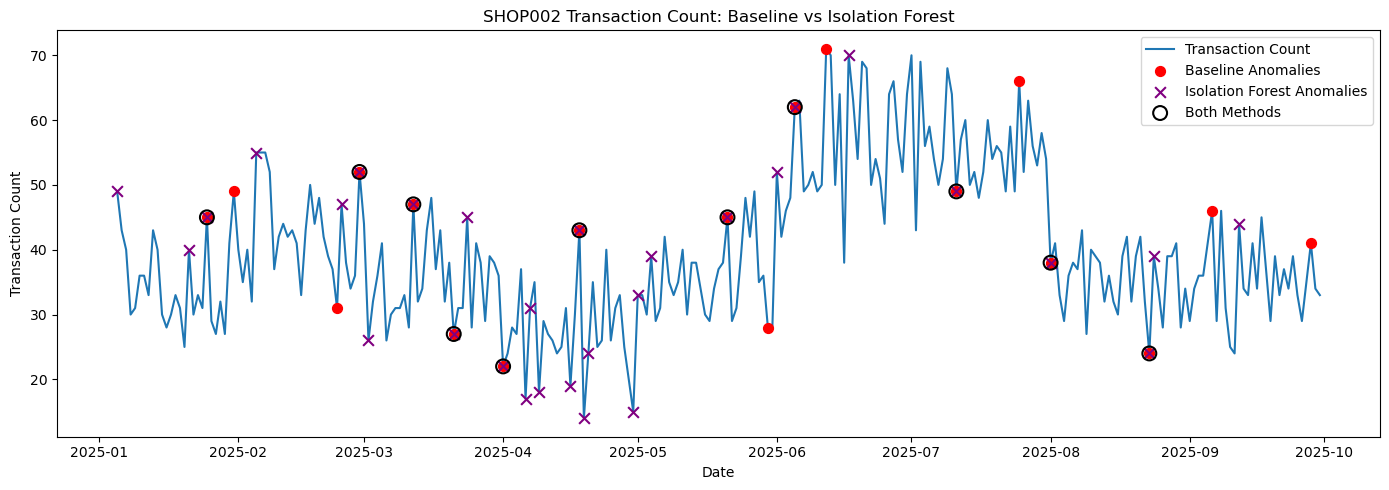

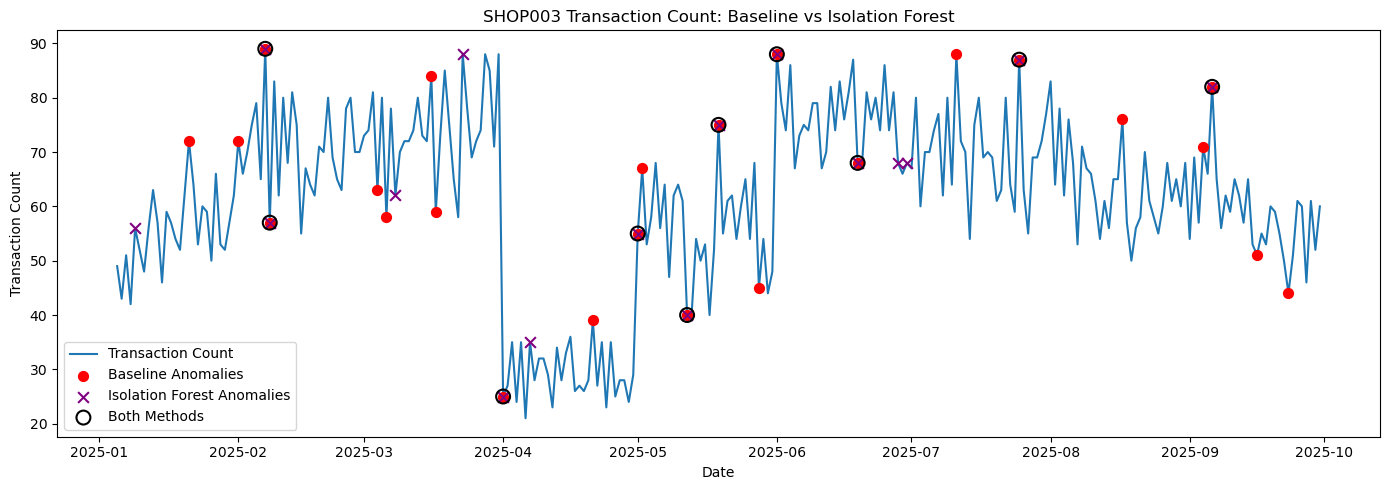

In [24]:
def plot_outlet_anomalies_clean(features, outlet_to_plot):
    shop_data = features[
        features["outlet"] == outlet_to_plot
    ].sort_values("date")

    baseline_points = shop_data[
        shop_data["baseline_anomaly_flag"] == 1
    ]

    iso_points = shop_data[
        shop_data["iso_anomaly_flag"] == 1
    ]

    both_points = shop_data[
        (shop_data["baseline_anomaly_flag"] == 1) &
        (shop_data["iso_anomaly_flag"] == 1)
    ]

    plt.figure(figsize=(14, 5), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    plt.plot(
        shop_data["date"],
        shop_data["transaction_count"],
        label="Transaction Count",
        linewidth=1.5
    )

    plt.scatter(
        baseline_points["date"],
        baseline_points["transaction_count"],
        color="red",
        label="Baseline Anomalies",
        s=50,
        zorder=3
    )

    plt.scatter(
        iso_points["date"],
        iso_points["transaction_count"],
        color="purple",
        label="Isolation Forest Anomalies",
        s=60,
        marker="x",
        zorder=4
    )

    plt.scatter(
        both_points["date"],
        both_points["transaction_count"],
        edgecolors="black",
        facecolors="none",
        label="Both Methods",
        s=100,
        marker="o",
        linewidths=1.5,
        zorder=5
    )

    plt.title(f"{outlet_to_plot} Transaction Count: Baseline vs Isolation Forest")
    plt.xlabel("Date")
    plt.ylabel("Transaction Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

for outlet in features["outlet"].unique():
    plot_outlet_anomalies_clean(features, outlet)

## Findings — Visual Comparison of Baseline and Isolation Forest Anomalies

Baseline and Isolation Forest anomalies were visualized across all outlets using daily transaction count.

### Key observations

The strongest anomaly candidates are generally detected by both methods. These points are shown using black hollow circles and represent high-confidence anomaly candidates.

Baseline-only anomalies appear as red points. These are rule-based anomalies where transaction volume or paid revenue crossed the selected rolling z-score threshold.

Isolation-Forest-only anomalies appear as purple markers. These represent machine learning anomaly candidates where the combination of multiple features appears unusual, even if the baseline z-score threshold was not crossed.

### Outlet-level interpretation

SHOP001 shows clear anomalies around the June demand increase, with both methods agreeing on several strong spike points.

SHOP002 shows more Isolation-Forest-only anomalies, suggesting that multivariate anomaly detection may add value for lower-volume or more variable outlet behavior.

SHOP003 shows clear structural changes around April and May, with both methods identifying important transition points and major spikes or drops.

### Interpretation

The visual comparison confirms that Isolation Forest adds useful anomaly candidates beyond the statistical baseline while still agreeing with the baseline on many of the strongest anomalies.

The strongest candidates for business review are the outlet-days detected by both methods.